In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

# Define data with missing (NaN) and duplicate values
data = pd.read_csv('pokemon_complete_stats.csv')


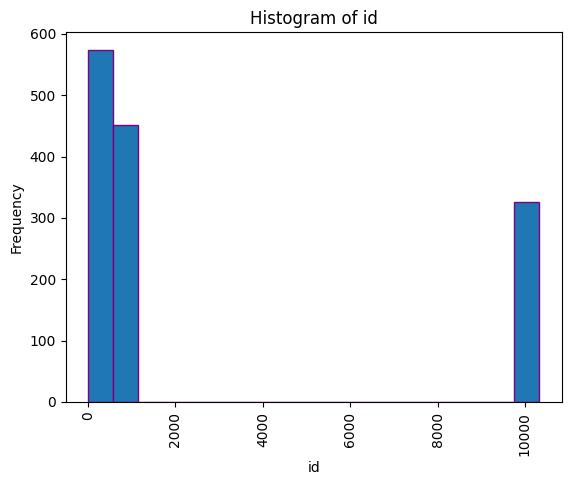

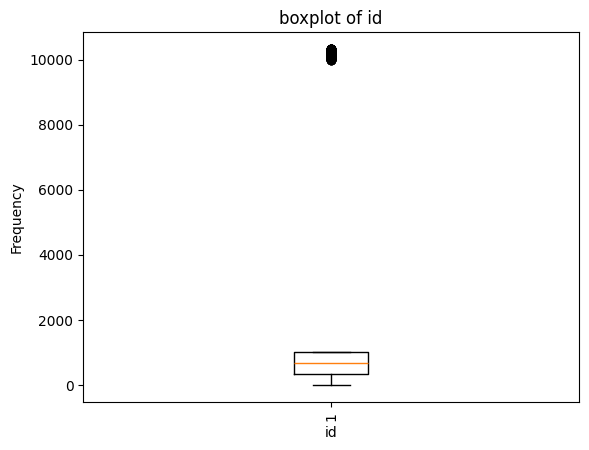

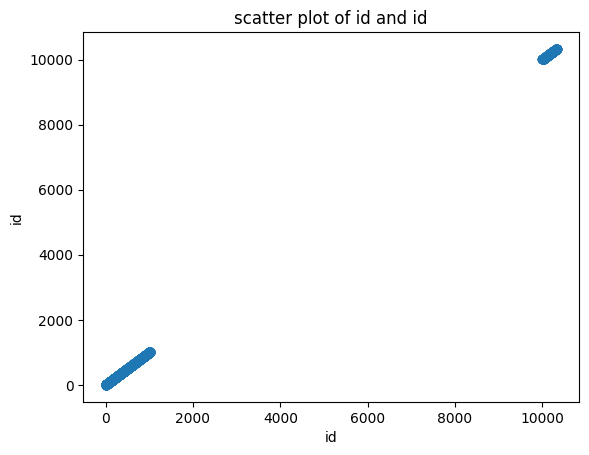

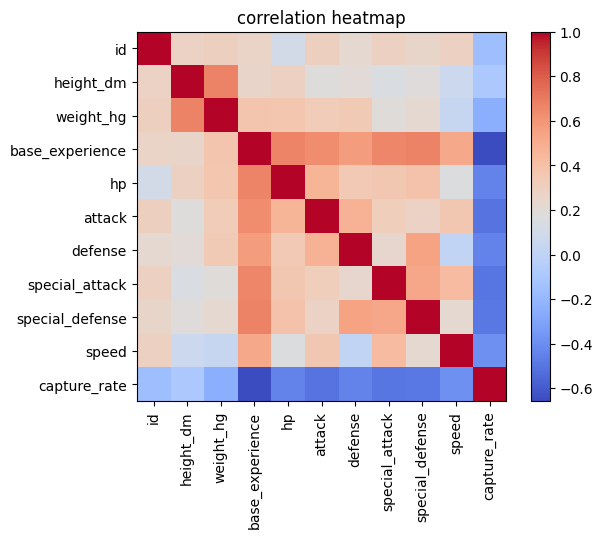

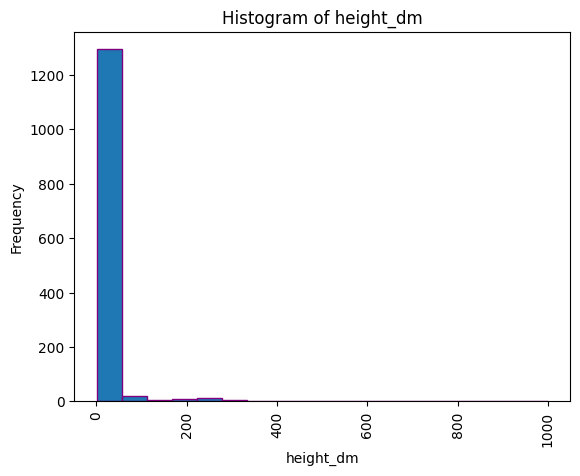

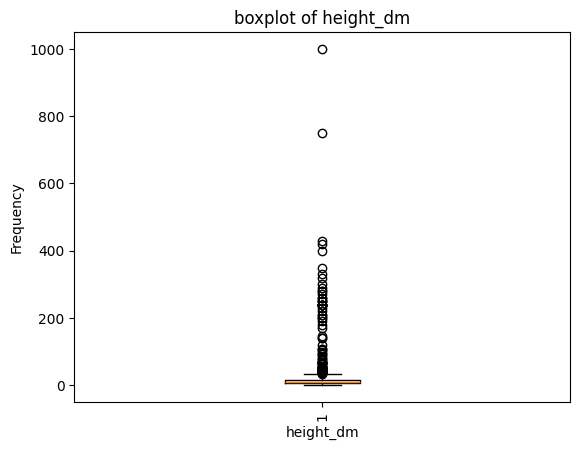

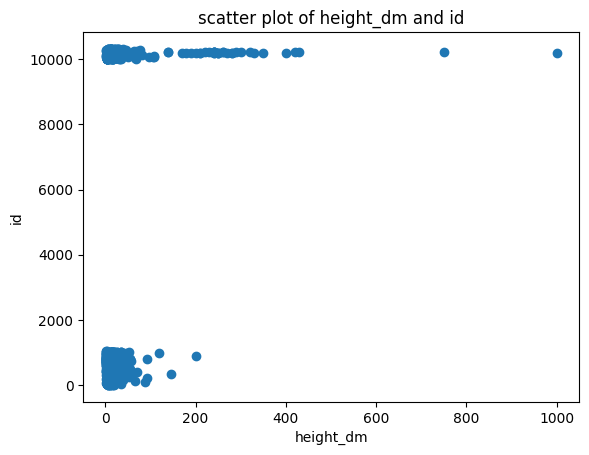

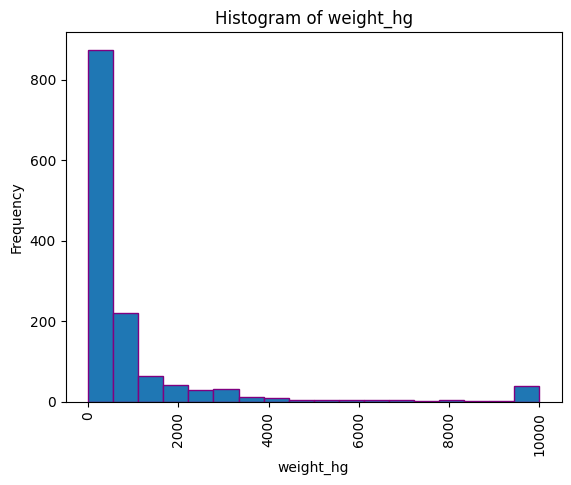

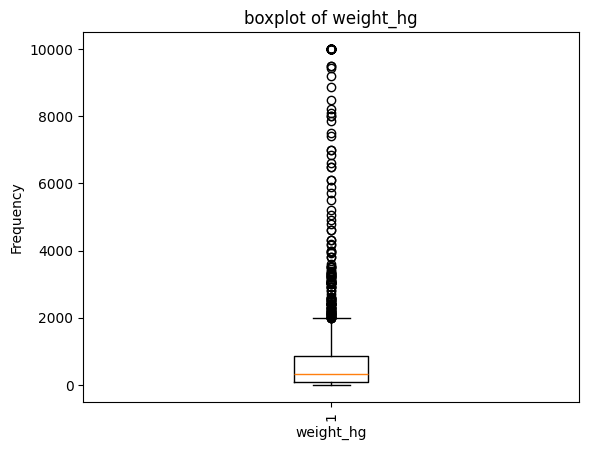

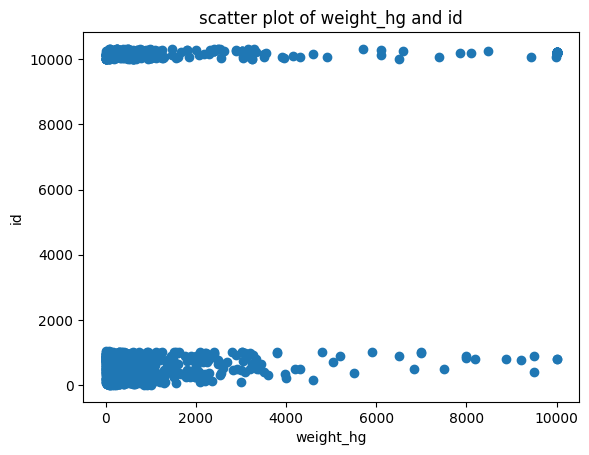

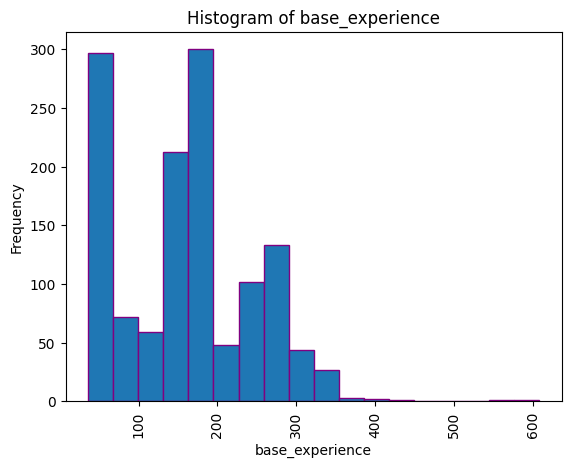

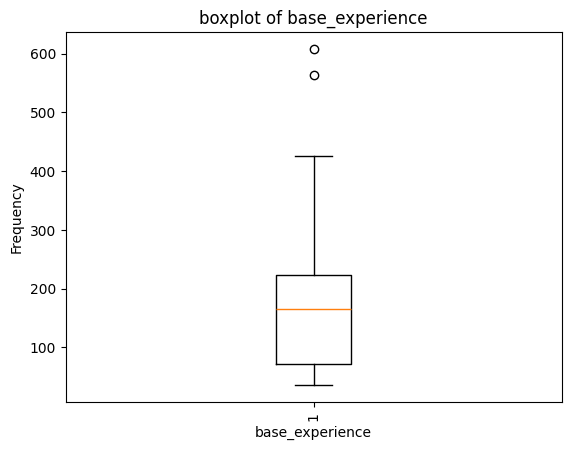

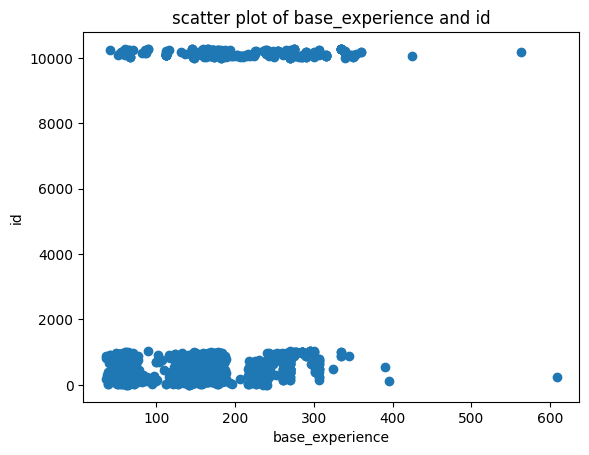

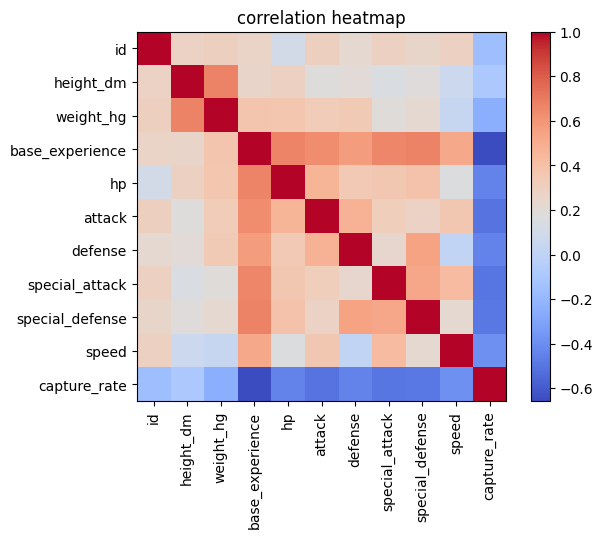

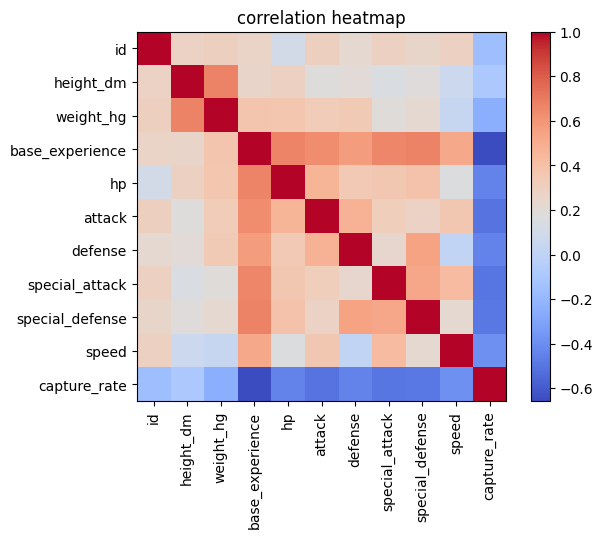

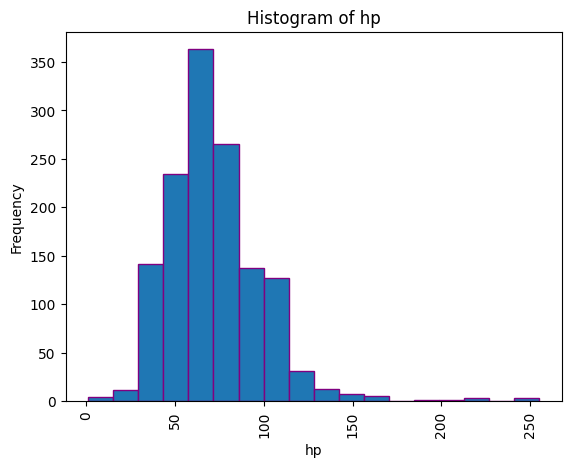

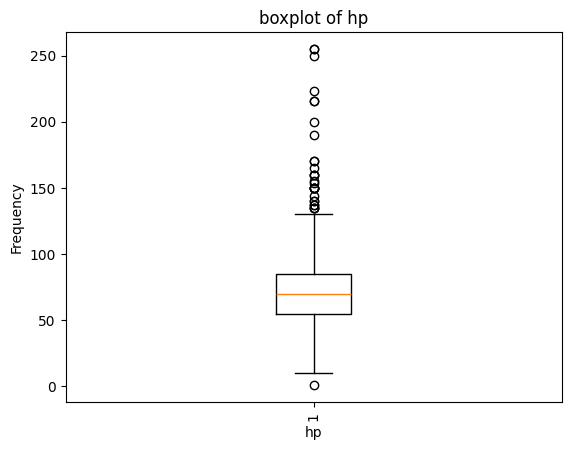

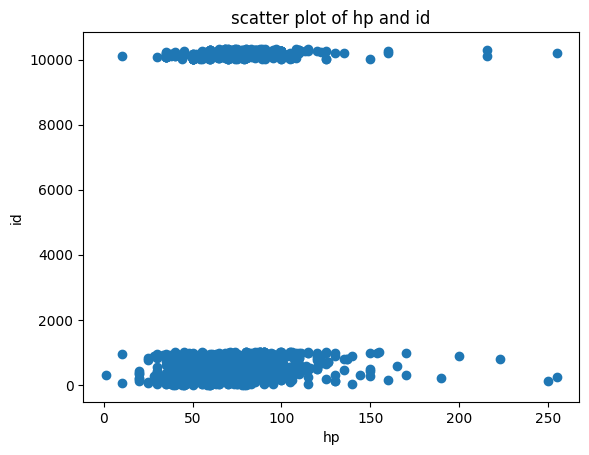

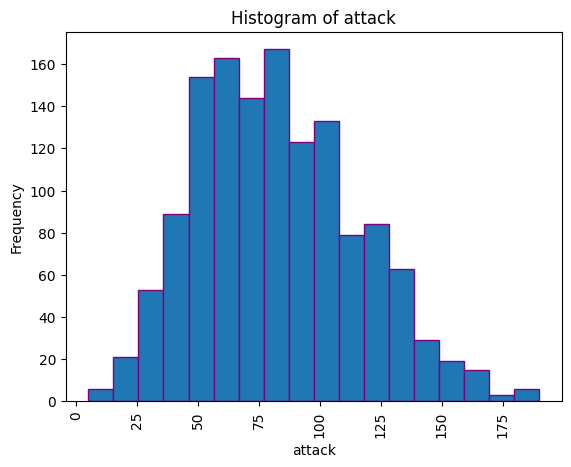

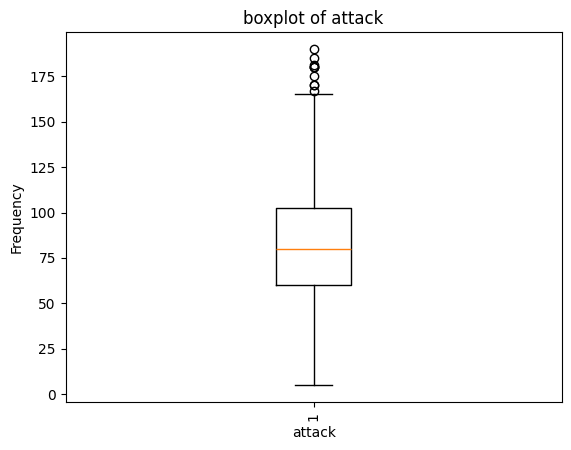

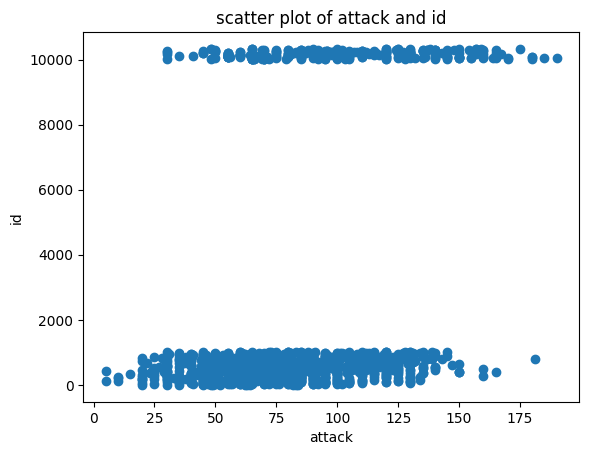

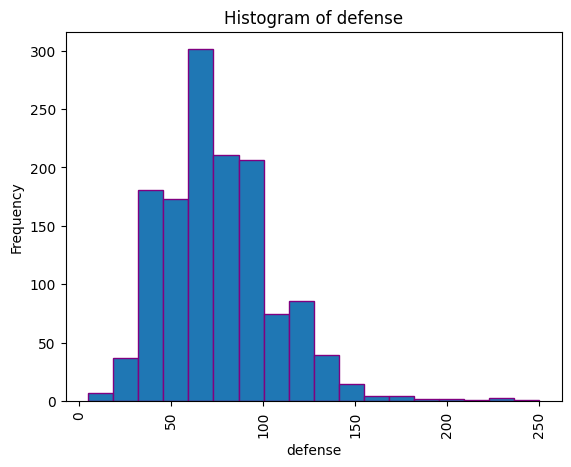

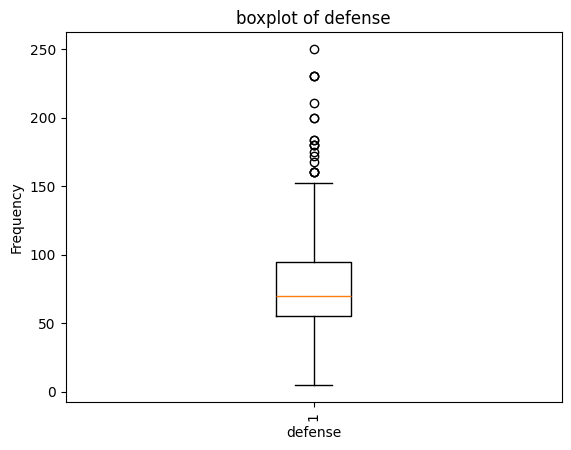

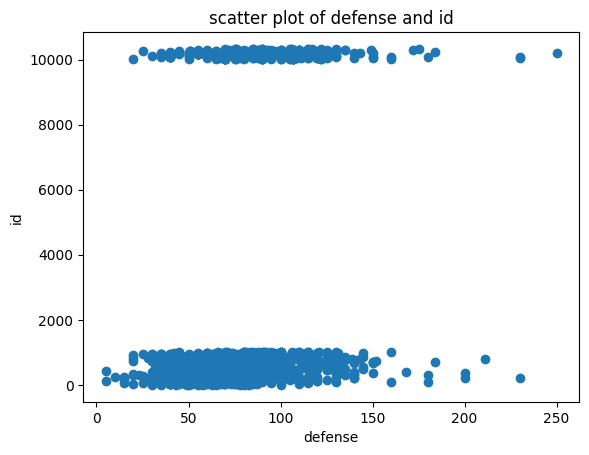

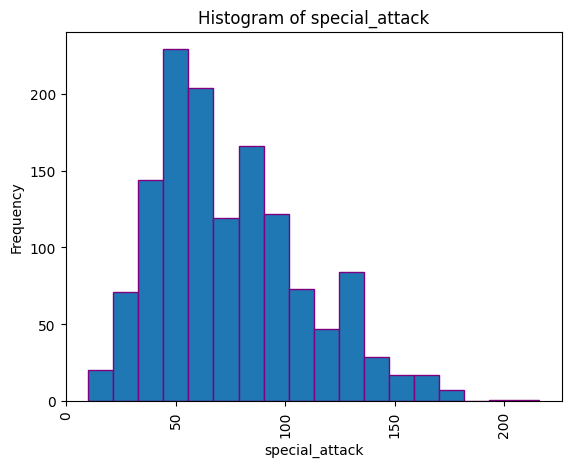

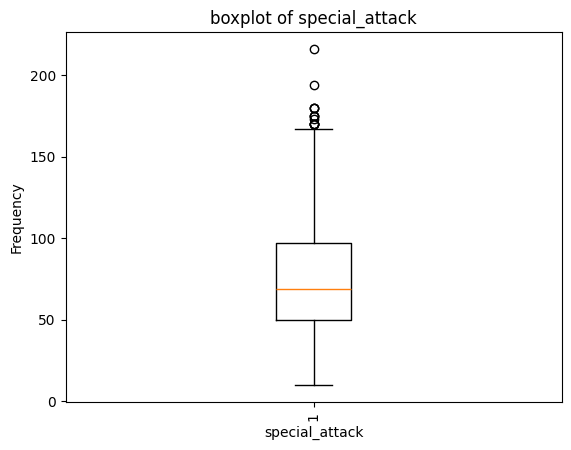

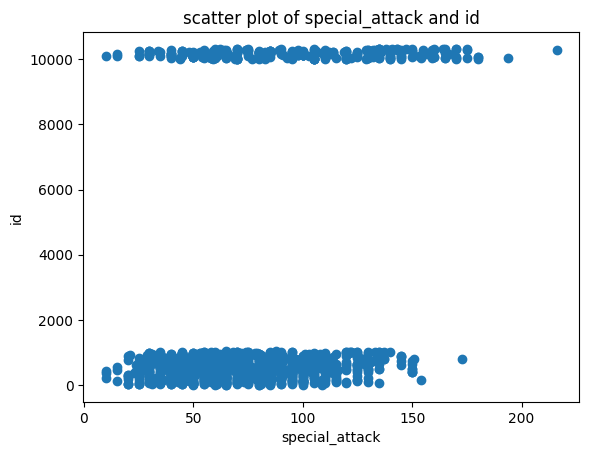

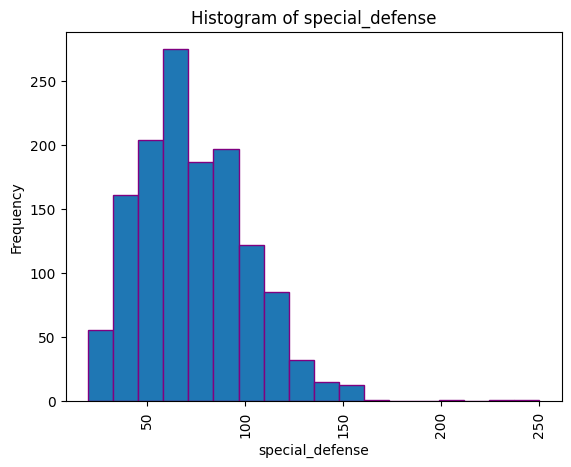

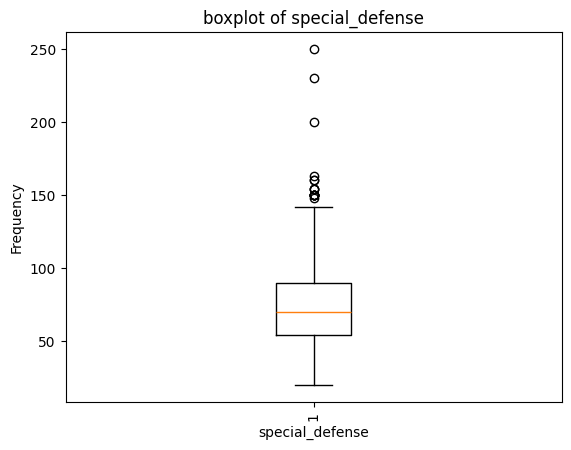

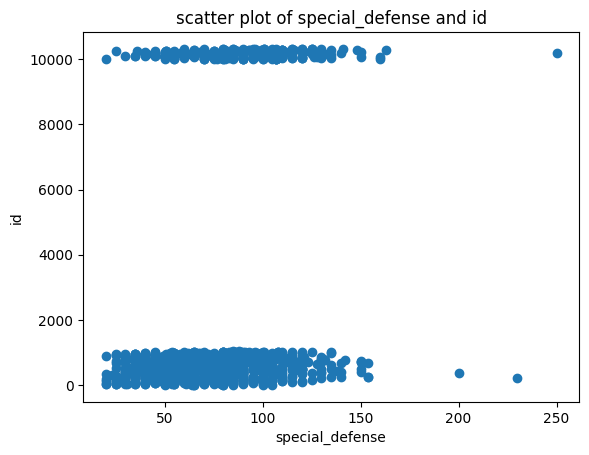

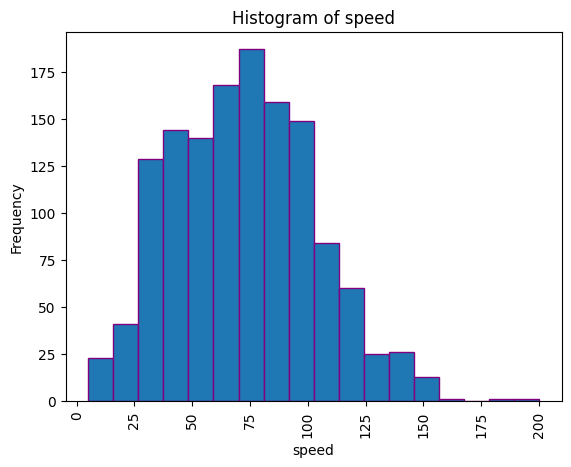

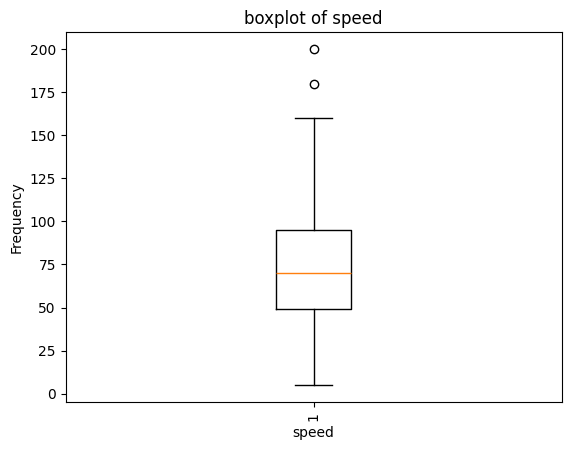

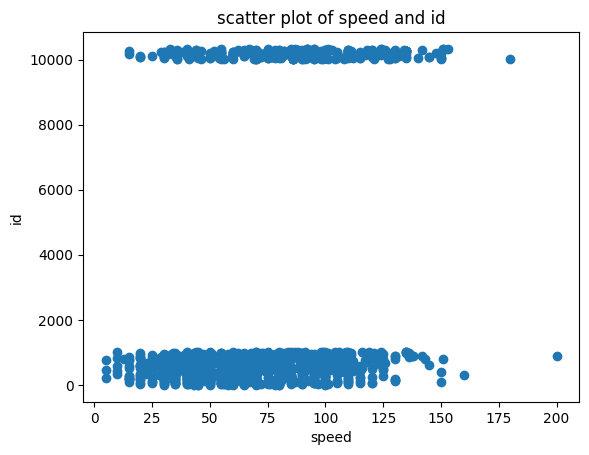

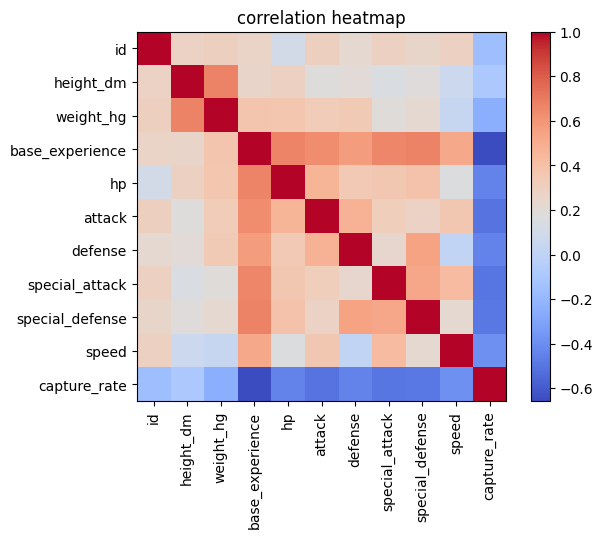

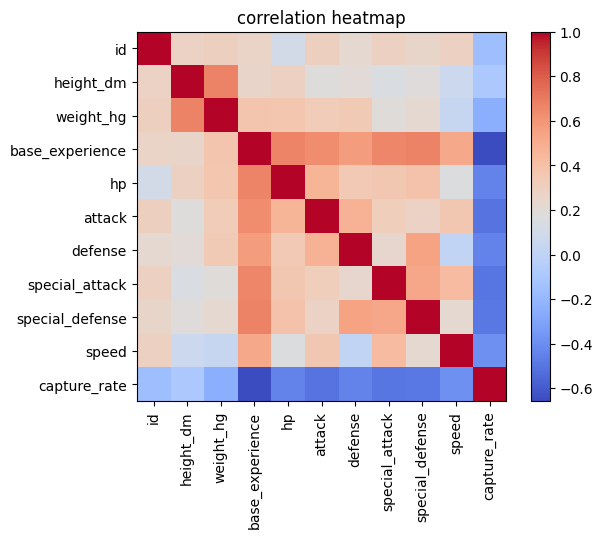

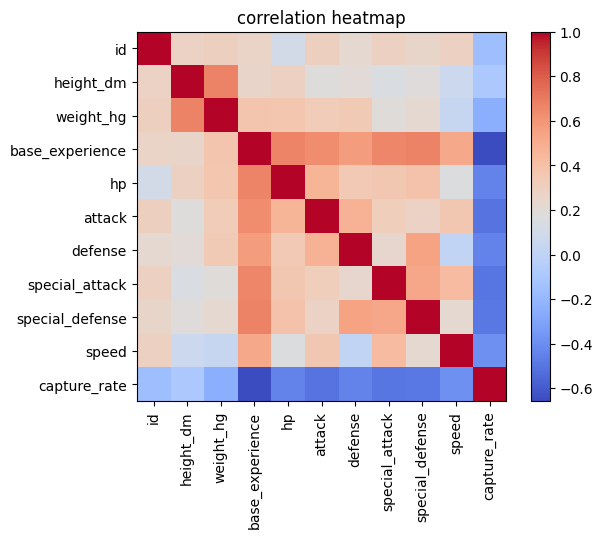

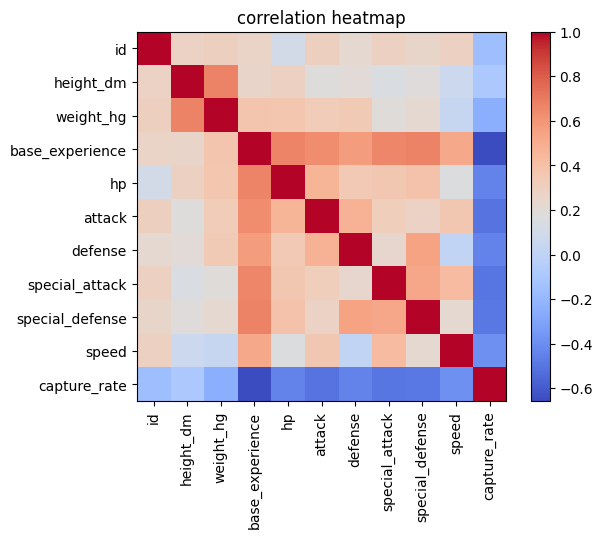

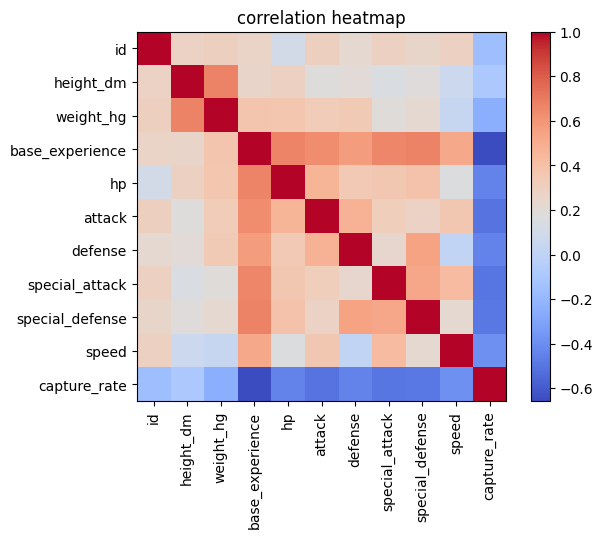

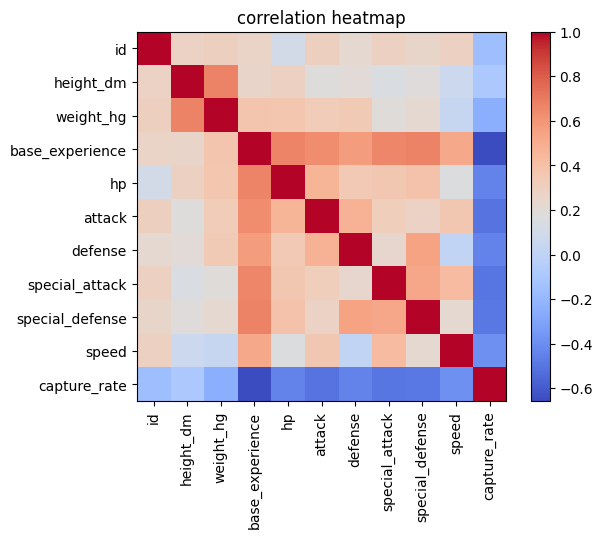

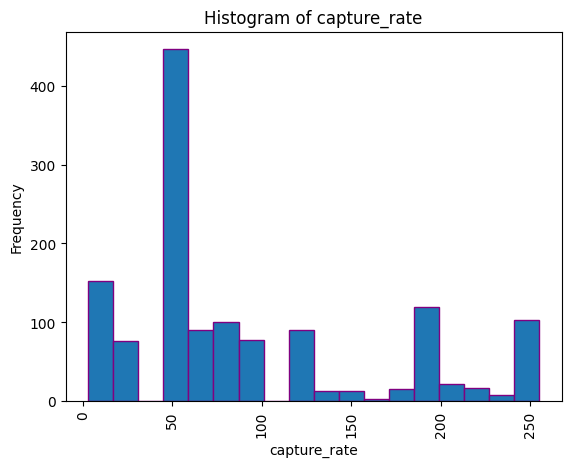

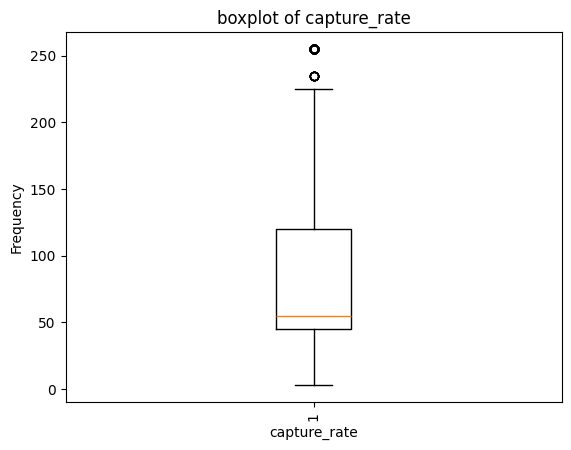

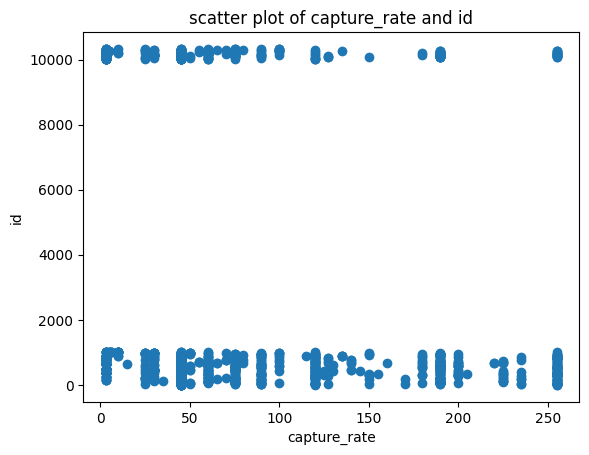

In [20]:
class EDA:
    def __init__(self , data):
        self.data = pd.DataFrame(data) if isinstance(data, dict) else data
        
    def shape(self):
        row , column = self.data.shape
        return {
            "row" : row,
            "column" : column 
               }
        
    def data_types(self):
        return self.data.dtypes
    
    def summary(self):
        return self.data.describe()
    
    def numeric_columns(self):
        return self.data.select_dtypes(include=[np.number]).columns.tolist()
    
    def categorical_columns(self):
        return self.data.select_dtypes(include=['object' , 'category']).columns.tolist()
    
    def unique_values(self ):
        return self.data.nunique()
    
    def correlation(self):
        numeric_data = self.data.select_dtypes(include=np.number)
        return numeric_data.corr()
    
    def histogram(self , column):
        if column in self.data.columns and not pd.api.types.is_bool_dtype(self.data[column]):
            plt.hist(self.data[column].dropna(), bins=18, edgecolor='purple')
            plt.title(f'Histogram of {column}')
            plt.xlabel(column)
            plt.xticks(rotation=90)
            plt.ylabel('Frequency')
            plt.show()  
        else:
            print(f"Column '{column}' does not exist in the DataFrame.")
            
    def boxplot(self , column ):
         if column in self.data.columns and not pd.api.types.is_bool_dtype(self.data[column]):
            plt.boxplot(self.data[column].dropna()) 
            plt.title(f'boxplot of {column}')
            plt.xlabel(column)
            plt.xticks(rotation=90)
            plt.ylabel('Frequency')
            plt.show()
         else:
             print(f'column {column} does not exist inn the dataframe')
             
    def scatter_plot(self , x_column , y_column):
         if x_column in self.data.columns and y_column in self.data.columns :
             plot = self.data[[x_column , y_column]].dropna()
             
             if plot.empty:
                 print(f'No data available for scatter plot of {x_column} and {y_column}')
                 return

             plt.scatter(plot[x_column], plot[y_column])
             plt.title(f'scatter plot of {x_column} and {y_column}') 
             plt.xlabel(x_column)
             plt.ylabel(y_column)
             plt.show()
         else:
             print(f'one or both column {x_column} and {y_column} do not exist in the DataFrame')
             
    def count_plot(self , column):
         if column in self.data.columns:
            counts = self.data[column].value_counts()
            plt.bar(counts.index , counts.values)
            plt.title(f'Count Plot of {column}')
            plt.xlabel(column)
            plt.ylabel('Count')
            plt.xticks(rotation=90)
            plt.show()
         else:
             print(f'Column {column} does not exist in the DataFrame')
             
    def correlation_heatmap(self):
        numeric_data = self.data.select_dtypes(include=np.number)
        correlation_matrix = numeric_data.corr()
        plt.imshow(correlation_matrix , cmap='coolwarm' , interpolation='nearest')
        plt.colorbar()
        plt.title('correlation heatmap')
        plt.xticks(range(len(correlation_matrix.columns)) , correlation_matrix.columns , rotation=90)
        plt.yticks(range(len(correlation_matrix.columns)) , correlation_matrix.columns)
        plt.show()
        
    def visualize(self , column=None):
        if column is None:
            self.correlation_heatmap()
        elif column in self.data.columns:
            if pd.api.types.is_numeric_dtype(self.data[column]) and not pd.api.types.is_bool_dtype(self.data[column]):
                self.histogram(column)
                self.boxplot(column)
                self.scatter_plot(column , self.numeric_columns()[0]) # Scatter plot with the first numeric column
                
            if column in self.categorical_columns():
                self.count_plot(column)
                
        else:
            print(f"column '{column}' does not exist in the dataframe")     
            
            
    def visualize_all(self):
        for column in self.data.columns:
            if pd.api.types.is_numeric_dtype(self.data[column]) and not pd.api.types.is_bool_dtype(self.data[column]):
                self.histogram(column)
                self.boxplot(column)
                numeric_columns = self.numeric_columns()
                if len(numeric_columns)>1:
                 self.scatter_plot(column , self.numeric_columns()[0])
            else:
                self.correlation_heatmap()
                                     
            
        
        
    def analyze(self):
        
        report = {}
        
        report['shape'] = self.shape()
        report['data_types'] = self.data_types()
        report['summary'] = self.summary()
        report['numeric_columns'] = self.numeric_columns()
        report['categorical_columns'] = self.categorical_columns()
        report['unique_values'] = self.unique_values()
        report['correlation'] = self.correlation()
        
        return report
    
eda = EDA(data)        
eda.visualize_all()      
            